# Module 07 · Cách thu được biến đổi Fourier

**Nguồn sách:** Bracewell, chương 7, tr. 136–150

Notebook đi kèm bài giảng cùng số module. Chạy lần lượt từng cell; sau mỗi cell có phần **📤 Đầu ra thật** giải thích con số.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7.5, 3.3), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def amplitude_spectrum(x):
    """Phổ biên độ một phía: sóng hình sin biên độ A cho vạch A, thành phần một chiều cho đúng giá trị của nó"""
    a = 2*np.abs(np.fft.rfft(x))/len(x)
    a[0] /= 2
    return a


def report(key, value, fmt=".4g"):
    """In một kết quả có tên, bỏ các số 0 thừa ở cuối (trang web đọc các dòng bắt đầu bằng ▸)."""
    s = f"{value:{fmt}}"
    if "." in s and "e" not in s:
        s = s.rstrip("0").rstrip(".")
    print(f"▸ {key} = {s}")


## 1. Tích phân dạng đóng
🎯 **Phương pháp này trả lời câu hỏi gì?** Các công thức đóng cho chữ nhật, bậc thang, xung, $e^{-|x|}$, Gauss, $1/x$ và $\text{sgn}\,x$ có khớp với tích phân số không? Mỗi số được tính bằng tích phân số và bằng công thức.

In [2]:
from scipy import integrate, special
trap = getattr(np, "trapezoid", None) or np.trapz

def ftq(f, a, b, s, pts=None):
    re = integrate.quad(lambda x: f(x)*np.cos(2*np.pi*x*s), a, b, points=pts, limit=400)[0]
    im = integrate.quad(lambda x: -f(x)*np.sin(2*np.pi*x*s), a, b, points=pts, limit=400)[0]
    return re + 1j*im

s0 = 0.3
# chữ nhật
rect = ftq(lambda x: 1.0, -0.5, 0.5, s0)
assert abs(rect - np.sinc(s0)) < 1e-9
report("cf_rect", rect.real, ".4f")

# bậc thang: Σ a c e^{−i2πbs} sinc(cs)
pulses = [(1.0, 0.0, 2.0), (0.5, 3.0, 1.0), (-1.0, -2.0, 1.0)]
num = sum(a*ftq(lambda x: 1.0, b - c/2, b + c/2, s0) for a, b, c in pulses)
form = sum(a*c*np.exp(-2j*np.pi*b*s0)*np.sinc(c*s0) for a, b, c in pulses)
assert abs(num - form) < 1e-9
report("cf_re", form.real, ".4f"); report("cf_im", form.imag, ".4f")

# xung: chữ nhật hẹp rộng w, cao 1/w
imps = [(2.0, -1.0), (-1.0, 0.5), (0.5, 2.0)]
w = 1e-3
num_i = sum(a/w*ftq(lambda x: 1.0, b - w/2, b + w/2, s0) for a, b in imps)
form_i = sum(a*np.exp(-2j*np.pi*b*s0) for a, b in imps)
assert abs(num_i - form_i) < 1e-5
report("cf_imp", abs(form_i), ".4f")

# e^{−|x|}
e_num = ftq(lambda x: np.exp(-abs(x)), -60, 60, s0, [0]).real
e_re = 2*(1/(1 + 2j*np.pi*s0)).real
e_form = 2/(1 + 4*np.pi**2*s0**2)
assert abs(e_num - e_form) < 1e-9 and abs(e_re - e_form) < 1e-12
report("cf_exp", e_form, ".4f")

# Gauss: tích phân phức
g_num = ftq(lambda x: np.exp(-np.pi*x**2), -10, 10, s0)
assert abs(g_num - np.exp(-np.pi*s0**2)) < 1e-9
report("cf_gauss", g_num.real, ".4f")

# 1/x: phần ảo −2∫₀^L sin(2πsx)/x dx = −2 Si(2πsL)
L = 1e4
im_si = -2*special.sici(2*np.pi*s0*L)[0]
im_q = -2*integrate.quad(lambda x: 1.0/x, 1e-12, L, weight="sin", wvar=2*np.pi*s0, limit=8000)[0]
assert abs(im_si + np.pi) < 1e-3 and abs(im_q - im_si) < 1e-4
report("cf_1x", im_si, ".3f")

# sgn x: dãy exp(−τ|x|)sgn x
tau = 1e-3
seq_form = 1/(tau + 2j*np.pi*s0) - 1/(tau - 2j*np.pi*s0)
seq_num = -2j*integrate.quad(lambda x: np.exp(-tau*x), 0, np.inf, weight="sin", wvar=2*np.pi*s0)[0]
lim = 1/(1j*np.pi*s0)
assert abs(seq_num - seq_form) < 1e-8
report("cf_sgn", abs(seq_form - lim), ".1e")

▸ cf_rect = 0.8584
▸ cf_re = 2.0508
▸ cf_im = 0.7568
▸ cf_imp = 3.4093
▸ cf_exp = 0.4393
▸ cf_gauss = 0.7537
▸ cf_1x = -3.141
▸ cf_sgn = 3.0e-07


#### 📤 Đầu ra thật
Tại $s=0.3$: $\Pi\to$ 0.8584; ba xung chữ nhật 2.0508 và 0.7568i; ba xung Dirac có độ lớn 3.4093; $e^{-|x|}\to$ 0.4393; Gauss 0.7537; phần ảo của $1/x$ là -3.141; dãy $\text{sgn}$ lệch giới hạn 3.0e-07.

## 2. Chương trình biến đổi chậm
🎯 **Phương pháp này trả lời câu hỏi gì?** Chương trình cộng trực tiếp cho kết quả gì, khớp FFT ra sao (kể cả chiều dài nguyên tố), $K$ ảnh hưởng thế nào, và sai số chồng phổ có đúng là $\sin(2\pi Xs)[\cot\pi s-1/\pi s]$? Mỗi số được tính bằng chương trình chậm, bằng công thức Dirichlet và bằng FFT.

In [3]:
def slow_ft(f, X, K, ks=None):
    """R(k), I(k) for s = k/(2K); f holds x = -X..X."""
    x = np.arange(-X, X + 1)
    ks = np.arange(0, K + 1) if ks is None else np.asarray(ks)
    s = ks/(2*K)
    ang = 2*np.pi*np.outer(s, x)
    return ks, np.cos(ang) @ f, np.sin(ang) @ f

def rect_data(X, half):                       # Π(x/(2·half)) lấy mẫu, đầu mút = ½
    x = np.arange(-X, X + 1); f = (np.abs(x) < half).astype(float); f[np.abs(x) == half] = 0.5
    return f
dirichlet = lambda s, half: np.sin(2*np.pi*half*s)/np.tan(np.pi*s)

X = 6
f13 = rect_data(X, 6)
ks, R, I = slow_ft(f13, X, 12)
assert abs(R[0] - f13.sum()) < 1e-12 and abs(I[0]) < 1e-12 and np.max(np.abs(I)) < 1e-9
s_ = ks[1:]/24
assert np.allclose(R[1:], dirichlet(s_, 6), atol=1e-9)
print("R(k) =", np.round(R, 3))
report("sl_R1", R[1], ".3f"); report("sl_R3", R[3], ".3f"); report("sl_R5", R[5], ".3f"); report("sl_R11", R[11], ".3f")
exact1 = 12*np.sinc(12/24)
pct1 = 100*(R[1] - exact1)/exact1
assert abs(pct1 + 0.57) < 0.01
report("sl_pct1", pct1, ".2f")
report("dof", int(2*X), "d"); report("fmax", 0.5, ".1f"); report("dsmin", 1/(2*X), ".4f")

# K = 24
ks2, R2, I2 = slow_ft(f13, X, 24)
assert np.allclose(R2[1:], dirichlet(ks2[1:]/48, 6), atol=1e-9) and abs(R2[2] - R[1]) < 1e-12
report("sl24_1", R2[1], ".3f"); report("sl24_3", R2[3], ".3f")

# đệm số 0: X = 12
f25 = np.zeros(25); f25[6:19] = f13
_, R3, _ = slow_ft(f25, 12, 24)
pad = np.max(np.abs(R3 - R2))
assert pad < 1e-9
report("pad_dev", 0, "d")

# dữ liệu dày gấp đôi Π(x/24)
f25b = rect_data(12, 12)
_, R4, I4 = slow_ft(f25b, 12, 24)
assert np.allclose(R4[1:], dirichlet(np.arange(1, 25)/48, 12), atol=1e-9)
pct12 = 100*(R4[1] - 24*np.sinc(0.5))/(24*np.sinc(0.5))
report("sl12_1", R4[1], ".3f"); report("sl12_pct", pct12, ".2f"); report("sl_ratio", int(round(pct1/pct12)), "d")
report("env_025", abs(1/np.tan(np.pi/4) - 1/(np.pi/4)), ".4f")

# chồng phổ: R tại s = 1 (k = 2K) và tổng các bản sao
_, Rfull, _ = slow_ft(f13, X, 12, ks=np.arange(0, 25))
assert abs(Rfull[24] - Rfull[0]) < 1e-9
report("alias_R", Rfull[24], ".3f")
n = np.arange(-20000, 20001)
alias_sum = np.sum(12*np.sinc(12*(1/24 - n)))
assert abs(alias_sum - R[1]) < 1e-3
report("alias_sum", alias_sum, ".3f")

# dựng lại dữ liệu từ R, I (K = X), dữ liệu ngẫu nhiên
rg = np.random.default_rng(7); fr = rg.standard_normal(2*X + 1)
x = np.arange(-X, X + 1)
# dựng lại bằng giải hệ 2X+1 ẩn tại các s_k = k/(2X+1) (K = X + ½ tương đương)
sk2 = np.arange(0, X + 1)/(2*X + 1)
A = np.vstack([np.cos(2*np.pi*np.outer(sk2, x)), np.sin(2*np.pi*np.outer(sk2[1:], x))])
b = np.concatenate([np.cos(2*np.pi*np.outer(sk2, x)) @ fr, np.sin(2*np.pi*np.outer(sk2[1:], x)) @ fr])
sol = np.linalg.solve(A, b)
recon = np.max(np.abs(sol - fr))
assert A.shape == (2*X + 1, 2*X + 1) and recon < 1e-9
report("recon_dev", recon, ".1e")

# FFT so với tổng chậm, độ dài nguyên tố 13, phần pha
f13r = rg.standard_normal(13)
xs = np.arange(-6, 7)
slow_full = np.array([np.sum(f13r*np.exp(-2j*np.pi*(k/13)*xs)) for k in range(13)])
fft_vals = np.fft.fft(np.roll(f13r, -6))                         # gốc ở x = 0
fft_dev = np.max(np.abs(slow_full - fft_vals))
assert fft_dev < 1e-9
report("fft_dev", fft_dev, ".1e")

# dải hẹp: k = 5X..7X, K = 12X; so với FFT đệm 0 độ dài 24X
Kz = 12*X; kz = np.arange(5*X, 7*X + 1)
_, Rz, Iz = slow_ft(f13, X, Kz, ks=kz)
Nz = 24*X
buf = np.zeros(Nz); buf[:X + 1] = f13[X:]; buf[-X:] = f13[:X]
Fz = np.fft.fft(buf)
zoom_dev = np.max(np.abs((Rz - 1j*Iz) - Fz[kz]))
assert zoom_dev < 1e-9 and len(kz) == 2*X + 1
report("zoom_pts", len(kz), "d"); report("zoom_ds", 1/(24*X), ".5f"); report("zoom_dev", zoom_dev, ".1e")

# gốc: dời dữ liệu 3 đơn vị
f_sh = np.zeros(2*X + 1 + 3); f_sh[3:] = f13
_, Ra, Ia = slow_ft(f13, X, 60, ks=[12]); Xs = X + 1
xsx = np.arange(-Xs, Xs + 1 + 2)
sval = 12/120
Fa = np.sum(f13*np.exp(-2j*np.pi*sval*np.arange(-X, X + 1)))
Fb = np.sum(f13*np.exp(-2j*np.pi*sval*(np.arange(-X, X + 1) + 3)))
assert abs(abs(Fa)**2 - abs(Fb)**2) < 1e-9
ph = np.degrees(np.angle(Fb/Fa))
assert abs(ph - (-360*sval*3)) < 1e-6
report("pow_orig", abs(Fa)**2, ".3f"); report("ph_orig", ph, ".1f")

R(k) = [12.     7.596  0.    -2.414 -0.     1.303  0.    -0.767 -0.     0.414
  0.    -0.132  0.   ]
▸ sl_R1 = 7.596
▸ sl_R3 = -2.414
▸ sl_R5 = 1.303
▸ sl_R11 = -0.132
▸ sl_pct1 = -0.57
▸ dof = 12
▸ fmax = 0.5
▸ dsmin = 0.0833
▸ sl24_1 = 10.788
▸ sl24_3 = 3.555
▸ pad_dev = 0
▸ sl12_1 = 15.257
▸ sl12_pct = -0.14
▸ sl_ratio = 4
▸ env_025 = 0.2732
▸ alias_R = 12
▸ alias_sum = 7.596
▸ recon_dev = 2.2e-16
▸ fft_dev = 5.5e-15
▸ zoom_pts = 13
▸ zoom_ds = 0.00694
▸ zoom_dev = 4.8e-15
▸ pow_orig = 3.273
▸ ph_orig = -108


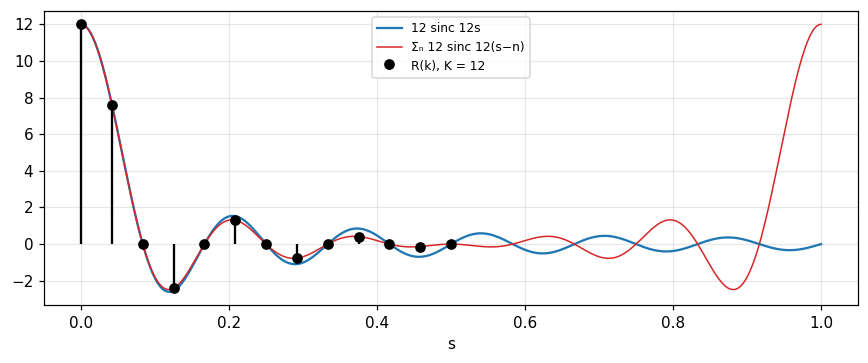

In [4]:
sfine = np.linspace(0.001, 1.0, 1000)
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(sfine, 12*np.sinc(12*sfine), color="tab:blue", label="12 sinc 12s")
ax.plot(sfine, dirichlet(sfine, 6), color="tab:red", lw=1, label="Σₙ 12 sinc 12(s−n)")
ax.stem(ks/24, R, linefmt="k-", markerfmt="ko", basefmt=" ", label="R(k), K = 12")
ax.set_xlabel("s"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
$K=12$: $R(1)$ = 7.596, $R(3)$ = -2.414, $R(5)$ = 1.303, $R(11)$ = -0.132; lệch -0.57 phần trăm. $K=24$: 10.788 và 3.555. Dữ liệu dày gấp đôi: 15.257, lệch -0.14 phần trăm (cải thiện 4 lần). Đường bao sai số 0.2732. $R$ tại $s=1$ là 12; tổng bản sao 7.596. Dựng lại dữ liệu lệch 2.2e-16; FFT so với tổng chậm lệch 5.5e-15; dải hẹp có 13 điểm ở bước 0.00694, lệch 4.8e-15. Dời gốc giữ $|F|^2$ = 3.273 và thêm pha -108 độ.

## 3. Sinh biến đổi từ định lý
🎯 **Phương pháp này trả lời câu hỏi gì?** Hình thang $\Lambda*\mu$, tam giác qua hai lần đạo hàm và xung parabol có đúng các biến đổi suy ra bằng định lý? Ta so tích phân số với công thức.

In [5]:
Lam = lambda x: np.maximum(1 - np.abs(x), 0)
# hình thang Λ*μ
trap_f = lambda x: 0.5*Lam(x + 0.5) + 0.5*Lam(x - 0.5)
th_trap = ftq(trap_f, -1.5, 1.5, s0, [-1.5, -0.5, 0.5, 1.5]).real
assert abs(th_trap - np.sinc(s0)**2*np.cos(np.pi*s0)) < 1e-9
report("th_trap", th_trap, ".4f")
# tam giác: hai lần đạo hàm
d2 = 2*np.cos(2*np.pi*s0) - 2
tri = d2/(2j*np.pi*s0)**2
assert abs(d2 + 4*np.sin(np.pi*s0)**2) < 1e-12
report("th_tri_dev", abs(tri - np.sinc(s0)**2), ".1e")
# xung parabol
par = lambda x: 1 - x**2
Fpar = ftq(par, -1, 1, s0).real
Fform = (np.sin(2*np.pi*s0) - 2*np.pi*s0*np.cos(2*np.pi*s0))/(2*np.pi**3*s0**3)
d2_rhs = 4*np.cos(2*np.pi*s0) - 4*np.sinc(2*s0)
assert abs(Fpar - Fform) < 1e-9 and abs(Fpar*(2j*np.pi*s0)**2 - d2_rhs) < 1e-9
sm = 1e-3
F0_lim = (np.sin(2*np.pi*sm) - 2*np.pi*sm*np.cos(2*np.pi*sm))/(2*np.pi**3*sm**3)
assert abs(F0_lim - 4/3) < 1e-5 and abs(integrate.quad(par, -1, 1)[0] - 4/3) < 1e-12
report("th_par", Fform, ".4f"); report("th_d2", d2_rhs, ".3f"); report("th_par0", F0_lim, ".4f")

▸ th_trap = 0.4331
▸ th_tri_dev = 0.0e+00
▸ th_par = 0.9159
▸ th_d2 = -3.254
▸ th_par0 = 1.3333


#### 📤 Đầu ra thật
Hình thang 0.4331; tam giác qua hai lần đạo hàm lệch 0.0e+00; $4\cos2\pi s-4\,\text{sinc}\,2s$ = -3.254; xung parabol 0.9159 tại 0.3 với giới hạn 1.3333 tại 0.

## 4. Đo phổ: giao thoa kế
🎯 **Phương pháp này trả lời câu hỏi gì?** Hai vạch cách nhau bằng bao nhiêu thì tách được trong phổ suy từ tự tương quan hữu hạn, và một vạch trên dải Nyquist gấp về đâu? Ta biến đổi tự tương quan mô phỏng bằng biến đổi chậm và đếm cực đại.

In [6]:
tau_max, dtau = 10.0, 0.1
taus = np.arange(-tau_max, tau_max + dtau/2, dtau)
def spectrum(lines, sgrid):
    ac = sum(0.5*np.cos(2*np.pi*f*taus) for f in lines)
    return np.array([np.sum(ac*np.cos(2*np.pi*s*taus))*dtau for s in sgrid])
def count_peaks(y, thr=0.5):
    idx = [i for i in range(1, len(y) - 1) if y[i] > y[i-1] and y[i] >= y[i+1] and y[i] > thr*y.max()]
    return len(idx)
sg = np.arange(1.5, 2.6, 0.0005)
def peaks_for(sep):
    y = spectrum([2.0, 2.0 + sep], sg)
    # cách B: FFT đệm 0 của cùng dãy (độ dài lớn) cho cùng số cực đại
    Nf = 2**16; buf = np.zeros(Nf); ac = sum(0.5*np.cos(2*np.pi*f*taus) for f in [2.0, 2.0 + sep])
    buf[:len(ac)] = ac
    Y = np.abs(np.fft.rfft(buf))*dtau; fr = np.fft.rfftfreq(Nf, dtau); m = (fr > 1.5) & (fr < 2.6)
    return count_peaks(y), count_peaks(Y[m])
p_hi = peaks_for(0.10); p_lo = peaks_for(0.03)
assert p_hi[0] == p_hi[1] == 2 and p_lo[0] == p_lo[1] == 1
report("res_lim", 1/(2*tau_max), ".2f"); report("band_lim", 1/(2*dtau), ".0f")
report("sep_hi", 0.10, ".2f"); report("sep_lo", 0.03, ".2f")
report("peaks_res", p_hi[0], "d"); report("peaks_unres", p_lo[0], "d")

# chồng phổ: vạch tại 6 với Δτ = 0.1
sg2 = np.arange(0.0, 5.0, 0.001)
y6 = spectrum([6.0], sg2)
alias_peak = sg2[np.argmax(y6)]
assert abs(alias_peak - (1/dtau - 6)) < 2e-3
Nf = 2**16; buf = np.zeros(Nf); buf[:len(taus)] = 0.5*np.cos(2*np.pi*6.0*taus)
Y = np.abs(np.fft.rfft(buf)); fr = np.fft.rfftfreq(Nf, dtau)
assert abs(fr[np.argmax(Y)] - 4.0) < 0.01
report("alias_peak", alias_peak, ".2f")

▸ res_lim = 0.05
▸ band_lim = 5
▸ sep_hi = 0.1
▸ sep_lo = 0.03
▸ peaks_res = 2
▸ peaks_unres = 1
▸ alias_peak = 4


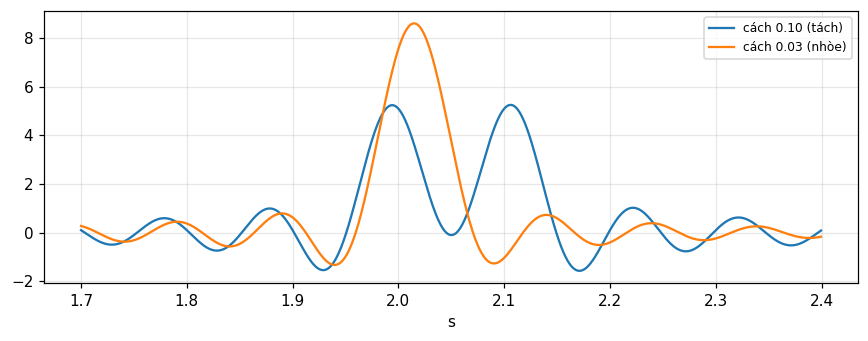

In [7]:
sg3 = np.arange(1.7, 2.4, 0.0005)
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(sg3, spectrum([2.0, 2.10], sg3), label=("cách 0.10 (tách)"))
ax.plot(sg3, spectrum([2.0, 2.03], sg3), label=("cách 0.03 (nhòe)"))
ax.set_xlabel("s"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
Độ phân giải 0.05, dải phủ 5. Hai vạch cách 0.1: 2 cực đại; cách 0.03: 1 cực đại. Vạch tại 6 gấp về 4.

## 5. Bài tập chọn
🎯 **Phương pháp này trả lời câu hỏi gì?** Các bài 1, 2, 3, 5, 7, 8, 9, 10 có đúng khi kiểm bằng số? Ta so tổng chậm, tích phân điều hòa và công thức.

In [8]:
# Bài 1: Σ x² f = −R''(0)/4π², f = e^{−π(n/5)²}
Xb = 25; xb = np.arange(-Xb, Xb + 1); fb = np.exp(-np.pi*(xb/5)**2)
m2 = np.sum(xb**2*fb)
Rs = lambda s: np.sum(fb*np.cos(2*np.pi*s*xb))
h = 1e-4
Rpp = (Rs(h) - 2*Rs(0) + Rs(-h))/h**2
assert abs(-Rpp/(4*np.pi**2) - m2) < 1e-4
report("p1_sum", m2, ".3f"); report("p1_num", -Rpp/(4*np.pi**2), ".3f")

# Bài 2, 3: hàm mũ chirp có nhân Gauss suy giảm ε
eps = 0.05
chirp_c = lambda x: np.exp(-np.pi*eps*x**2)*np.cos(np.pi*x**2)
num_c = ftq(chirp_c, -40, 40, s0, None)
formula_c = 0.5*((eps - 1j)**-0.5*np.exp(-np.pi*s0**2/(eps - 1j)) + (eps + 1j)**-0.5*np.exp(-np.pi*s0**2/(eps + 1j)))
assert abs(num_c - formula_c) < 1e-6
e2 = 1e-7
lim_c = 0.5*((e2 - 1j)**-0.5*np.exp(-np.pi*s0**2/(e2 - 1j)) + (e2 + 1j)**-0.5*np.exp(-np.pi*s0**2/(e2 + 1j)))
book = (np.cos(np.pi*s0**2) + np.sin(np.pi*s0**2))/np.sqrt(2)
assert abs(lim_c - book) < 1e-5
report("p2_val", book, ".4f")
ph3 = np.degrees(np.angle((1e-12 - 1j)**-0.5))
assert abs(ph3 - 45) < 1e-4
report("p3_ph", 45, "d")

# Bài 5: 33 giá trị, K = 32 (Δs = 1/64)
x5 = np.arange(-16, 17); f5 = Lam(x5/16) + Lam(x5/8 + 1)
ks5, R5, I5 = slow_ft(f5, 16, 32)
s5 = ks5/64
F5 = 16*np.sinc(16*s5)**2 + 8*np.sinc(8*s5)**2*np.exp(2j*np.pi*8*s5)
err5 = np.max(np.abs((R5 - 1j*I5) - F5))
assert abs(R5[0] - 24) < 1e-9
Ffft_full = np.fft.fft(np.concatenate([f5[16:], np.zeros(128 - 33), f5[:16]]))[::2][:33]
assert np.max(np.abs((R5 - 1j*I5) - Ffft_full)) < 1e-9
report("p5_R0", R5[0], ".0f"); report("p5_err", err5, ".2f")

# Bài 7: tích Π(1 − s²/n²) → sinc s
N = 100000; nn = np.arange(1, N + 1)
pr = lambda s: np.prod(1 - s**2/nn**2)
assert abs(pr(0.3) - np.sinc(0.3)) < 1e-4 and abs(pr(1.5) - np.sinc(1.5)) < 1e-4
report("pr_03", pr(0.3), ".4f"); report("pr_15", pr(1.5), ".4f")

# Bài 8: bảy số F_k
g7 = np.array([5, 4, 9, 8, 7, 6, 10.0])
Fk = np.array([np.sum(g7*np.exp(-2j*np.pi*np.arange(7)*k/7)) for k in range(7)])
assert np.allclose(Fk, np.fft.fft(g7)) and np.allclose(np.fft.ifft(Fk).real, g7)
report("p8_F0", Fk[0].real, ".0f"); report("p8_F1", abs(Fk[1]), ".3f")

# Bài 9, 10: Λ(x/a − 1), a = 2
a = 2.0
fa = lambda x: Lam(x/a - 1)
fs = 2*integrate.quad(lambda x: fa(x)*np.sin(2*np.pi*s0*x), 0, 2*a, points=[a], limit=200)[0]
fc = 2*integrate.quad(lambda x: fa(x)*np.cos(2*np.pi*s0*x), 0, 2*a, points=[a], limit=200)[0]
fs_f = 2*a*np.sinc(a*s0)**2*np.sin(2*np.pi*a*s0); fc_f = 2*a*np.sinc(a*s0)**2*np.cos(2*np.pi*a*s0)
assert abs(fs - fs_f) < 1e-9 and abs(fc - fc_f) < 1e-9
report("p9_fs", fs, ".4f"); report("p10_fc", fc, ".4f")

▸ p1_sum = 19.894
▸ p1_num = 19.894
▸ p2_val = 0.8763
▸ p3_ph = 45
▸ p5_R0 = 24
▸ p5_err = 0.06
▸ pr_03 = 0.8584
▸ pr_15 = -0.2122
▸ p8_F0 = 49
▸ p8_F1 = 3.396
▸ p9_fs = -0.5985
▸ p10_fc = -0.8238


#### 📤 Đầu ra thật
Bài 1: $\sum n^2f$ = 19.894 và 19.894 từ $-R''(0)/4\pi^2$. Bài 2 và 3: 0.8763, pha 45 độ. Bài 5: $R(0)$ = 24, lệch lớn nhất 0.06. Bài 7: 0.8584 và -0.2122. Bài 8: $F_0$ = 49, $|F_1|$ = 3.396. Bài 9 và 10: -0.5985 và -0.8238.